In [40]:
!pip install imbalanced-learn==0.6.0
!pip install scikit-learn==0.22.1


  Using cached scikit-learn-0.22.1.tar.gz (6.9 MB)
  Preparing metadata (setup.py) ... done
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error
  ERROR: Failed building wheel for scikit-learn
  Running setup.py clean for scikit-learn
Failed to build scikit-learn
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (scikit-learn)


In [41]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from scipy import stats
from scipy.stats import boxcox
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder
from scipy.stats import boxcox
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV 

In [42]:
#1 Dataset Description
#From the first view, this dataset is about determining the special features(mostly health care related) that can cause a stroke
#Important features include age, smoking hsitory, previous heart diseases, gender , bmi, etc

In [43]:
df = pd.read_csv(r"/kaggle/input/healthcaree/healthcare-dataset-stroke-data.csv")
df.head(5) #produces runtime warning possibly due to missing values

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [44]:
df['gender'].value_counts()
df = df[df['gender']!='Other'] #Removed the other
df['gender'].value_counts()
df['smoking_status'].value_counts()#no typo
df['Residence_type'].value_counts() #no typos in this dataset

Residence_type
Urban    2596
Rural    2513
Name: count, dtype: int64

In [45]:
#Categorical encoding
#one hot encoding for only 2 values
df = pd.get_dummies(df, columns=['gender', 'ever_married' , 'Residence_type'], drop_first=True)
df.head(1)
df['gender_Male'] = df['gender_Male'].astype(int) #convert to numerical
df['ever_married_Yes'] = df['ever_married_Yes'].astype(int)
df['Residence_type_Urban'] = df['Residence_type_Urban'].astype(int)
df.head(1)

,id,age,hypertension,heart_disease,work_type,avg_glucose_level,bmi,smoking_status,stroke,gender_Male,ever_married_Yes,Residence_type_Urban
0,9046,67.0,0,1,Private,228.69,36.6,formerly smoked,1,1,1,1


In [46]:
df['bmi'].isnull().sum()
imputer = KNNImputer(n_neighbors=5) #5 neighbours
df[['bmi']] = pd.DataFrame(imputer.fit_transform(df[['bmi']]))
df['bmi'].isnull().sum()# filled missing values

1

In [47]:
smoking_order = ['Unknown', 'never smoked', 'formerly smoked', 'smokes']
home_safety_order = ['children', 'Never_worked', 'Self-employed', 'Private', 'Govt_job']
encoder = OrdinalEncoder(categories=[smoking_order, home_safety_order])
df[['smoke_encoded', 'job_encoded']] = encoder.fit_transform(df[['smoking_status', 'work_type']])
df.head(1)

,id,age,hypertension,heart_disease,work_type,avg_glucose_level,bmi,smoking_status,stroke,gender_Male,ever_married_Yes,Residence_type_Urban,smoke_encoded,job_encoded
0,9046,67.0,0,1,Private,228.69,36.6,formerly smoked,1,1,1,1,2.0,3.0


In [48]:
df.drop(columns=['smoking_status', 'work_type'])

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,Residence_type_Urban,smoke_encoded,job_encoded
0,9046,67.0,0,1,228.69,36.60000,1,1,1,1,2.0,3.0
1,51676,61.0,0,0,202.21,28.89456,1,0,1,0,1.0,2.0
2,31112,80.0,0,1,105.92,32.50000,1,1,1,0,1.0,3.0
3,60182,49.0,0,0,171.23,34.40000,1,0,1,1,3.0,3.0
4,1665,79.0,1,0,174.12,24.00000,1,0,1,0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,80.0,1,0,83.75,40.00000,0,0,1,1,1.0,3.0
5106,44873,81.0,0,0,125.20,30.60000,0,0,1,1,1.0,2.0
5107,19723,35.0,0,0,82.99,25.60000,0,0,1,0,1.0,2.0
5108,37544,51.0,0,0,166.29,26.20000,0,1,1,0,2.0,3.0


In [49]:
df['smoke_encoded'] = df['smoke_encoded'].replace(0.0,np.nan) # changing unknown in smoking to be null
df['smoke_encoded'].isnull().sum()

1544

In [50]:
df[['smoke_encoded']] = pd.DataFrame(imputer.fit_transform(df[['smoke_encoded']]))
df['smoke_encoded'].isnull().sum()# filled missing values (question why is there always a one left)
df = df.drop(index=5109) #drop that annoying row

In [51]:
df = df.drop(columns=['smoking_status', 'work_type'])

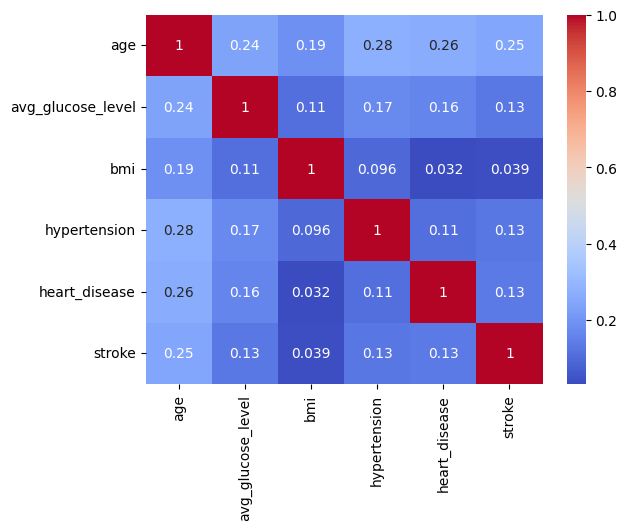

In [52]:
correlation_matrix = df.loc[:,('age','avg_glucose_level','bmi','hypertension','heart_disease','stroke')].corr()
correlation_matrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show() #no issue with correlations

In [53]:
df.head(10)

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,Residence_type_Urban,smoke_encoded,job_encoded
0,9046,67.0,0,1,228.69,36.60000,1,1,1,1,2.000000,3.0
1,51676,61.0,0,0,202.21,28.89456,1,0,1,0,1.000000,2.0
2,31112,80.0,0,1,105.92,32.50000,1,1,1,0,1.000000,3.0
3,60182,49.0,0,0,171.23,34.40000,1,0,1,1,3.000000,3.0
4,1665,79.0,1,0,174.12,24.00000,1,0,1,0,1.000000,2.0
5,56669,81.0,0,0,186.21,29.00000,1,1,1,1,2.000000,3.0
6,53882,74.0,1,1,70.09,27.40000,1,1,1,0,1.000000,3.0
7,10434,69.0,0,0,94.39,22.80000,1,0,0,1,1.000000,3.0
8,27419,59.0,0,0,76.15,28.89456,1,0,1,0,1.690603,3.0
9,60491,78.0,0,0,58.57,24.20000,1,0,1,1,1.690603,3.0


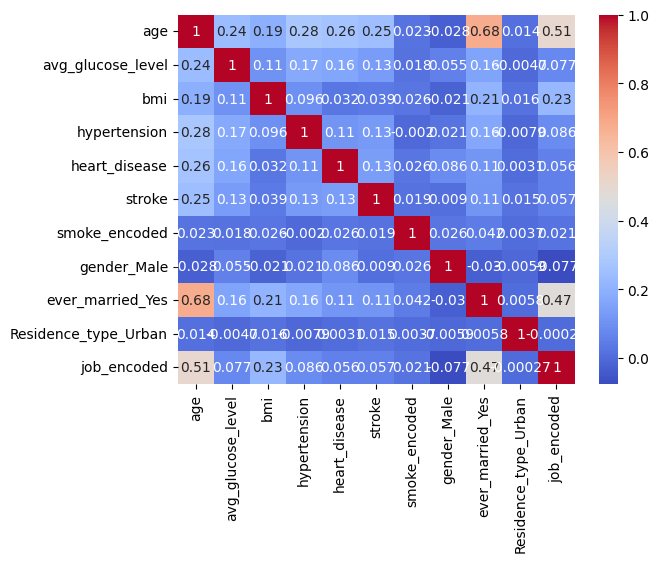

In [54]:
correlation_matrix = df.loc[:,('age','avg_glucose_level','bmi','hypertension','heart_disease','stroke', 'smoke_encoded', 'gender_Male','ever_married_Yes','Residence_type_Urban', 'job_encoded')].corr()
correlation_matrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show() # just to make sure

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


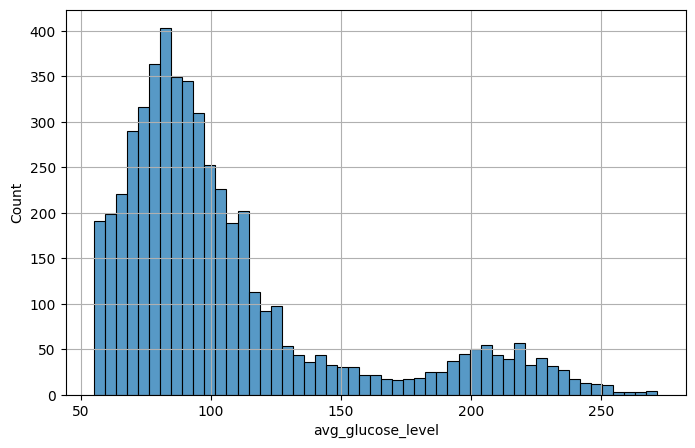

In [55]:
#Histogram plots to spot skewness
plt.figure(figsize=(8, 5))
sns.histplot(x=df['avg_glucose_level'])
plt.xlabel('avg_glucose_level')
plt.grid(True)
plt.show() # skewness

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


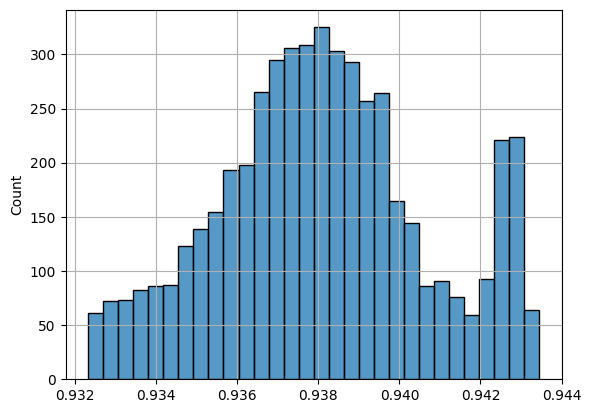

In [56]:
newGlucArr = boxcox(df["avg_glucose_level"])
newGluc = newGlucArr[0]
sns.histplot(newGluc) # more normal
plt.grid(True)
plt.show() #no skewness
df["avg_glucose_level"] = newGluc

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


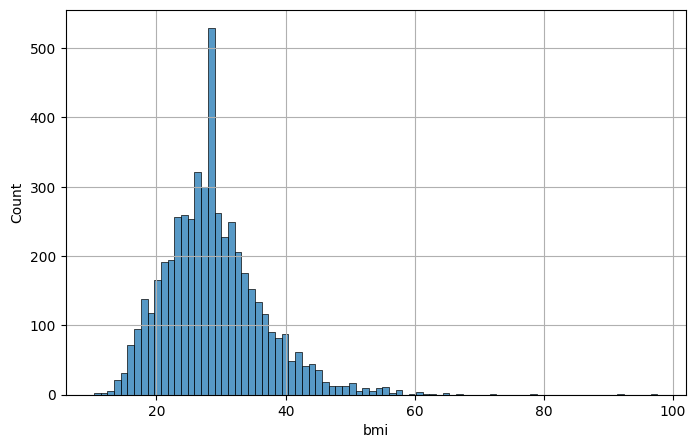

In [57]:
#Histogram plots to spot skewness
plt.figure(figsize=(8, 5))
sns.histplot(x=df['bmi'])
plt.xlabel('bmi')
plt.grid(True)
plt.show() # skewness

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


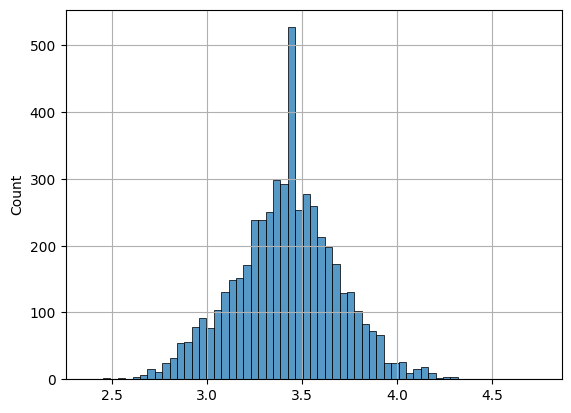

In [58]:
newBMIArr = boxcox(df["bmi"])
newBMI = newBMIArr[0]
sns.histplot(newBMI) # more normal
plt.grid(True)
plt.show() #no skewness
df["bmi"] = newBMI

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


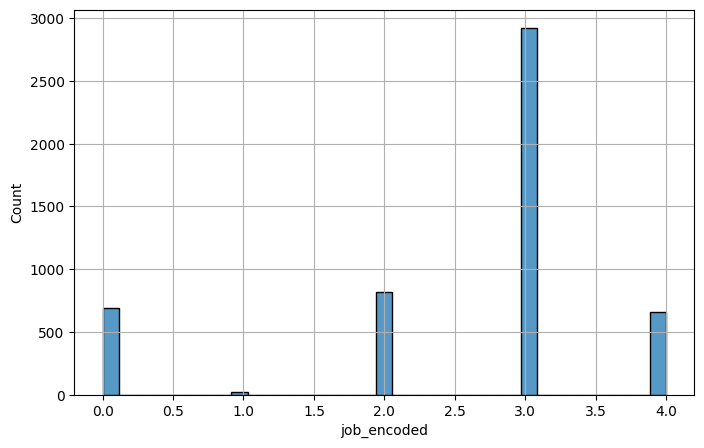

In [59]:
plt.figure(figsize=(8, 5))
sns.histplot(x=df['job_encoded'])
plt.xlabel('job_encoded')
plt.grid(True)
plt.show() # skewness

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


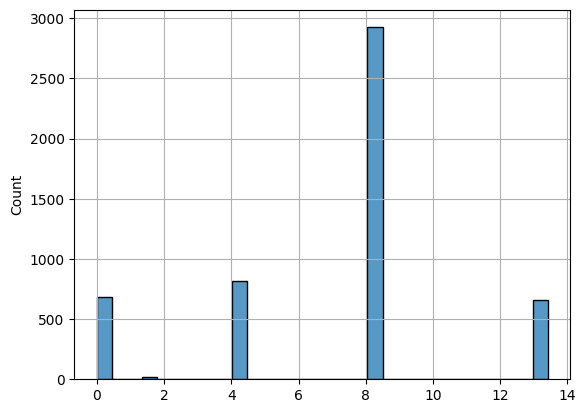

In [60]:
newJobArr = boxcox(df["job_encoded"] +1) #added to remove negatives
newJob = newJobArr[0]
sns.histplot(newJob) # more normal
plt.grid(True)
plt.show() #no skewness
df["job_encoded"] = newJob

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


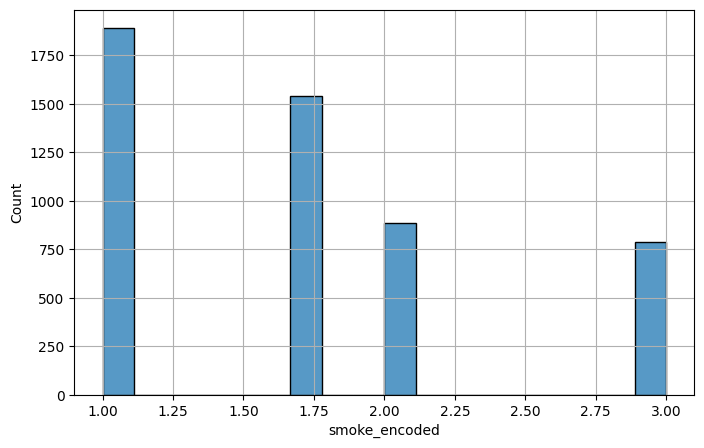

In [61]:
plt.figure(figsize=(8, 5))
sns.histplot(x=df['smoke_encoded'])
plt.xlabel('smoke_encoded')
plt.grid(True)
plt.show() #no skewness

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


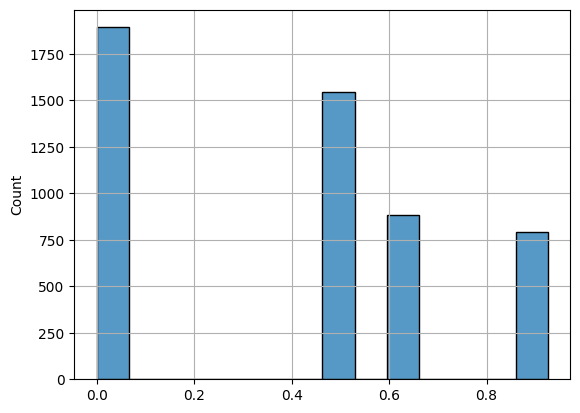

In [62]:
newSmokeArr = boxcox(df["smoke_encoded"])
newSmoke = newSmokeArr[0]
sns.histplot(newSmoke) # more normal
plt.grid(True)
plt.show() #still some
df["smoke_encoded"] = newSmoke


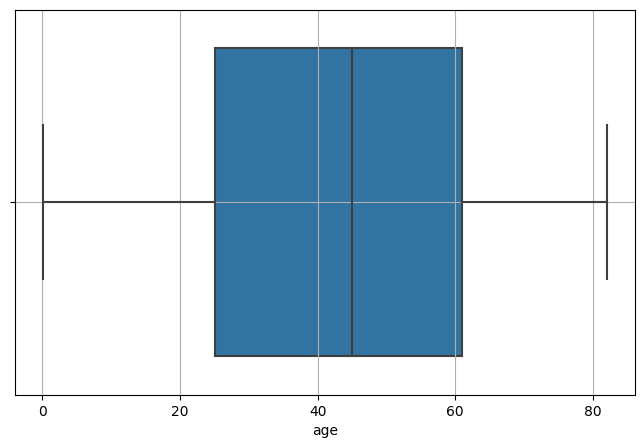

In [63]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['age'])
plt.xlabel('age')
plt.grid(True)
plt.show() #Perfect

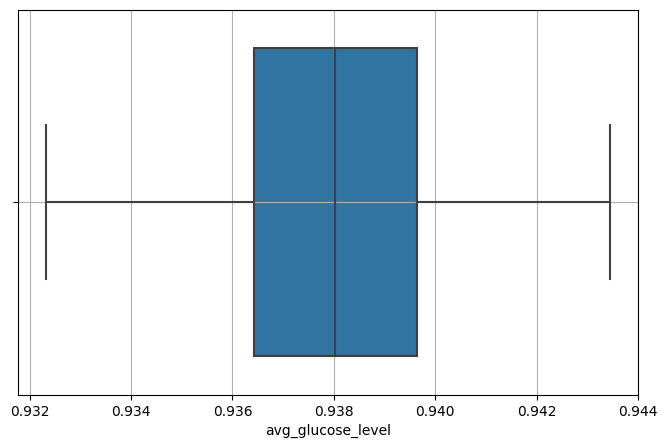

In [64]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['avg_glucose_level'])
plt.xlabel('avg_glucose_level')
plt.grid(True)
plt.show() #Perfect

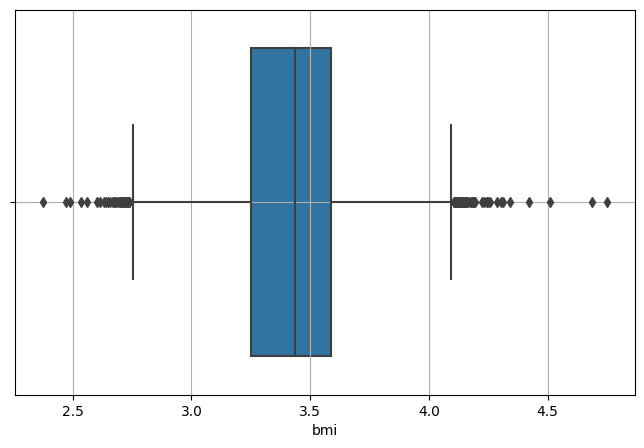

In [65]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['bmi'])
plt.xlabel('bmi')
plt.grid(True)
plt.show() #outliers



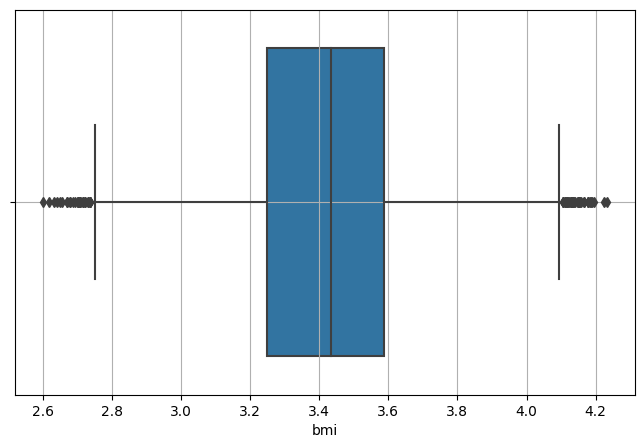

In [66]:
z_scores = stats.zscore(df["bmi"]) #getting outliers
outliers_z = df[(np.abs(z_scores) > 3)]  # Threshold at 3 
df = df.drop(outliers_z.index) #cleaning them
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['bmi'])
plt.xlabel('bmi')
plt.grid(True)
plt.show() #removed some

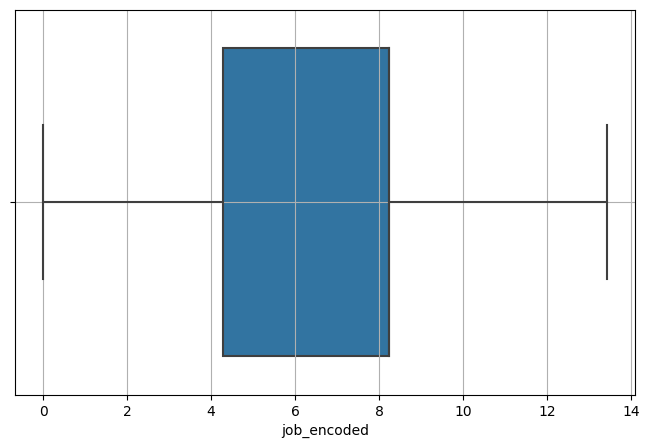

In [67]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['job_encoded'])
plt.xlabel('job_encoded')
plt.grid(True)
plt.show() #Perfect
# plt.figure(figsize=(8, 5))
# sns.boxplot(x=df['smoke_encoded'])
# plt.xlabel('smoke_encoded')
# plt.grid(True)
# plt.show() #Perfect

In [68]:
# Checking duplicates
df.duplicated().sum() #none

0

<Axes: xlabel='stroke'>

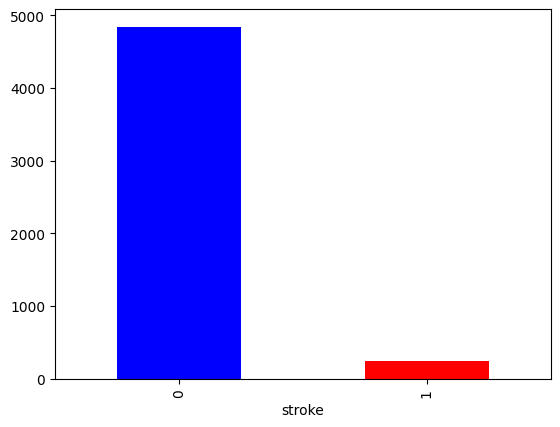

In [69]:
x_df = df.drop(columns='stroke')
y_df = df[["stroke"]]
y_df['stroke'].value_counts().plot.bar(color=['blue', 'red'])


In [70]:
#Splitting the data
X_train, X_test, y_train, y_test = train_test_split( x_df, y_df, test_size=0.30, random_state=0)

In [71]:
log_transformer = FunctionTransformer(np.log1p, validate=True)

pipeline = Pipeline([
    ('log', log_transformer),
    ('scaler', StandardScaler())
])

X_train_scaled = pipeline.fit_transform(X_train)

# transforming X_test
X_test_scaled = pipeline.transform(X_test)

<Axes: >

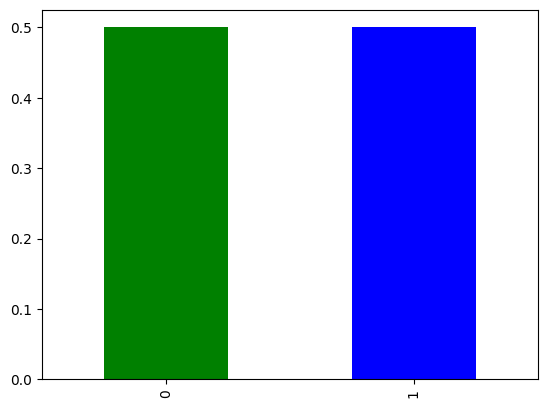

In [72]:
#Fixing imbalanced data using SMOTE
sm = SMOTE(random_state = 2)
X_train_scaled, y_train = sm.fit_resample(X_train_scaled, y_train.values.ravel())
X_train_scaled.shape #data increased
pd.Series(y_train).value_counts(normalize=True).plot.bar(color=['green', 'blue', 'red'])
#class imbalance fixed

In [73]:
def evaluate_metrics(yt, yp):
    results_pos = {}
    results_pos['accuracy'] = accuracy_score(yt, yp)
    precision, recall, f_beta, _ = precision_recall_fscore_support(yt, yp, average='weighted')
    results_pos['recall'] = recall
    results_pos['precision'] = precision
    results_pos['f1score'] = f_beta
    return results_pos

In [74]:
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

# predictions
y_pred = model.predict(X_test_scaled)
evaluate_metrics(y_test,y_pred)

{'accuracy': 0.7323298429319371,
 'recall': 0.7323298429319371,
 'precision': 0.9427264142513039,
 'f1score': 0.8084781766628469}

In [135]:
# Hard Linear SVM 
svm_linear = SVC(kernel='linear', class_weight='balanced', random_state=42, C=100) #C should be larger but running time is very long
svm_linear.fit(X_train_scaled, y_train)

y_pred_hard = svm_linear.predict(X_test_scaled)
# Model Evaluation
print("SVM (Linear Kernel)")
print("Accuracy:", accuracy_score(y_test, y_pred_hard))

SVM (Linear Kernel)
Accuracy: 0.7022251308900523


In [90]:
# Soft Linear SVM 
param_grid = {'C': [0.1, 1, 10, 40, 100, 200, 500]}

grid = GridSearchCV(SVC(kernel='linear', class_weight='balanced', random_state=42), param_grid, refit = True, verbose = 3) 
 
grid.fit(X_train_scaled, y_train)
# Model Evaluation
best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
print("SVM Results:")
print(f"Best C: {grid.best_params_['C']}")
print(f"Test Accuracy: {test_accuracy}") #same result


Fitting 5 folds for each of 7 candidates, totalling 35 fits
[CV 1/5] END .............................C=0.1;, score=0.803 total time=   0.8s
[CV 2/5] END .............................C=0.1;, score=0.810 total time=   0.9s
[CV 3/5] END .............................C=0.1;, score=0.807 total time=   0.9s
[CV 4/5] END .............................C=0.1;, score=0.813 total time=   0.9s
[CV 5/5] END .............................C=0.1;, score=0.804 total time=   0.9s
[CV 1/5] END ...............................C=1;, score=0.807 total time=   1.1s
[CV 2/5] END ...............................C=1;, score=0.810 total time=   1.2s
[CV 3/5] END ...............................C=1;, score=0.810 total time=   1.2s
[CV 4/5] END ...............................C=1;, score=0.813 total time=   1.1s
[CV 5/5] END ...............................C=1;, score=0.804 total time=   1.2s
[CV 1/5] END ..............................C=10;, score=0.808 total time=   2.9s
[CV 2/5] END ..............................C=10;,

In [96]:
# Kernel rbf SVM 
param_grid = {'C': [0.1, 1, 10, 50, 100, 500, 1000], 
			'gamma': [1, 0.1, 0.01, 0.001, 0.0001]}

grid = GridSearchCV(SVC(kernel='rbf', class_weight='balanced', random_state=42), param_grid, refit = True, verbose = 3) 
 
grid.fit(X_train_scaled, y_train)
# Model Evaluation
best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
print("SVM Results:")
print(f"Best C: {grid.best_params_['C']}")
print(f"Best gamma: {grid.best_params_['gamma']}")
print(f"Test Accuracy: {test_accuracy}")
# Fitting 5 folds for each of 35 candidates, totalling 175 fits
# SVM Results:
# Best C: 10
# Best gamma: 1
# Test Accuracy: 0.9155759162303665*/

Fitting 5 folds for each of 35 candidates, totalling 175 fits
[CV 1/5] END ....................C=0.1, gamma=1;, score=0.867 total time=   1.6s
[CV 2/5] END ....................C=0.1, gamma=1;, score=0.892 total time=   1.8s
[CV 3/5] END ....................C=0.1, gamma=1;, score=0.902 total time=   1.8s
[CV 4/5] END ....................C=0.1, gamma=1;, score=0.895 total time=   1.7s
[CV 5/5] END ....................C=0.1, gamma=1;, score=0.899 total time=   1.8s
[CV 1/5] END ..................C=0.1, gamma=0.1;, score=0.814 total time=   1.1s
[CV 2/5] END ..................C=0.1, gamma=0.1;, score=0.838 total time=   1.3s
[CV 3/5] END ..................C=0.1, gamma=0.1;, score=0.823 total time=   1.3s
[CV 4/5] END ..................C=0.1, gamma=0.1;, score=0.822 total time=   1.2s
[CV 5/5] END ..................C=0.1, gamma=0.1;, score=0.820 total time=   1.3s
[CV 1/5] END .................C=0.1, gamma=0.01;, score=0.757 total time=   1.4s
[CV 2/5] END .................C=0.1, gamma=0.01

In [100]:
# # Kernel polynomial SVM 
param_grid = {'C': [0.1, 1, 10, 50, 100, 500, 1000], 
			'degree': [2, 3, 4, 5]}

grid = GridSearchCV(SVC(kernel='poly', class_weight='balanced', random_state=42), param_grid, refit = True, verbose = 3) 
 
grid.fit(X_train_scaled, y_train)
# Model Evaluation
best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
print("SVM Results:")
print(f"Best C: {grid.best_params_['C']}")
print(f"Best degree: {grid.best_params_['degree']}")
print(f"Test Accuracy: {test_accuracy}")
# SVM Results:
# Best C: 1000
# Best degree: 4
# Test Accuracy: 0.8756544502617801

Fitting 5 folds for each of 28 candidates, totalling 140 fits
[CV 1/5] END ...................C=0.1, degree=2;, score=0.751 total time=   1.1s
[CV 2/5] END ...................C=0.1, degree=2;, score=0.748 total time=   1.3s
[CV 3/5] END ...................C=0.1, degree=2;, score=0.751 total time=   1.3s
[CV 4/5] END ...................C=0.1, degree=2;, score=0.739 total time=   1.2s
[CV 5/5] END ...................C=0.1, degree=2;, score=0.739 total time=   1.2s
[CV 1/5] END ...................C=0.1, degree=3;, score=0.771 total time=   1.1s
[CV 2/5] END ...................C=0.1, degree=3;, score=0.751 total time=   1.3s
[CV 3/5] END ...................C=0.1, degree=3;, score=0.755 total time=   1.2s
[CV 4/5] END ...................C=0.1, degree=3;, score=0.738 total time=   1.1s
[CV 5/5] END ...................C=0.1, degree=3;, score=0.758 total time=   1.2s
[CV 1/5] END ...................C=0.1, degree=4;, score=0.721 total time=   1.1s
[CV 2/5] END ...................C=0.1, degree=4

In [101]:
# Kernel sigmoid SVM 
param_grid = {'C': [0.1, 1, 10, 50, 100, 500, 1000]}

grid = GridSearchCV(SVC(kernel='sigmoid', class_weight='balanced', random_state=42), param_grid, refit = True, verbose = 3) 
 
grid.fit(X_train_scaled, y_train)
# Model Evaluation
best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
print("SVM Results:")
print(f"Best C: {grid.best_params_['C']}")
print(f"Test Accuracy: {test_accuracy}")

Fitting 5 folds for each of 7 candidates, totalling 35 fits
[CV 1/5] END .............................C=0.1;, score=0.701 total time=   1.9s
[CV 2/5] END .............................C=0.1;, score=0.728 total time=   2.1s
[CV 3/5] END .............................C=0.1;, score=0.734 total time=   2.1s
[CV 4/5] END .............................C=0.1;, score=0.732 total time=   2.0s
[CV 5/5] END .............................C=0.1;, score=0.707 total time=   2.0s
[CV 1/5] END ...............................C=1;, score=0.650 total time=   1.3s
[CV 2/5] END ...............................C=1;, score=0.643 total time=   1.5s
[CV 3/5] END ...............................C=1;, score=0.659 total time=   1.4s
[CV 4/5] END ...............................C=1;, score=0.677 total time=   1.5s
[CV 5/5] END ...............................C=1;, score=0.628 total time=   1.5s
[CV 1/5] END ..............................C=10;, score=0.638 total time=   1.1s
[CV 2/5] END ..............................C=10;,

In [102]:

# Initializing pca without specifiying n_components
pca = PCA()

pca.fit(X_train_scaled)

# explained variance ratio
explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

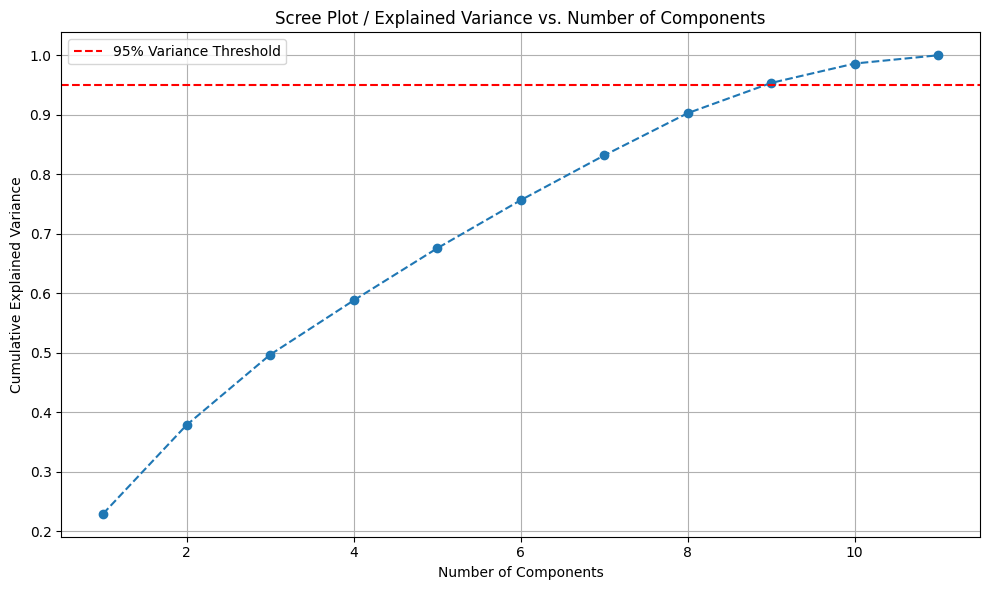

In [103]:
# Scree Plot (Explained Variance)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_var) + 1), cum_var, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot / Explained Variance vs. Number of Components')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [111]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [115]:
logreg_pca = LogisticRegression(class_weight='balanced', random_state=42)

# fitting training data after pca
logreg_pca.fit(X_train_pca, y_train)

# predictions
y_pred_lr_pca = logreg_pca.predict(X_test_pca)
evaluate_metrics(y_test,y_pred_lr_pca)

{'accuracy': 0.7676701570680629,
 'recall': 0.7676701570680629,
 'precision': 0.9335939063239892,
 'f1score': 0.831986748764301}

In [116]:
# Kernel rbf SVM with PCA
param_grid = {'C': [0.1, 1, 10, 50, 100, 500, 1000], 
			'gamma': [1, 0.1, 0.01, 0.001, 0.0001]}

grid = GridSearchCV(SVC(kernel='rbf', class_weight='balanced', random_state=42), param_grid, refit = True, verbose = 3) 
 
grid.fit(X_train_pca, y_train)
# Model Evaluation
best_svm = grid.best_estimator_
y_pred_pca = best_svm.predict(X_test_pca)
test_accuracy = accuracy_score(y_test, y_pred_pca)
print("SVM Results:")
print(f"Best C: {grid.best_params_['C']}")
print(f"Best gamma: {grid.best_params_['gamma']}")
print(f"Test Accuracy: {test_accuracy}")
# SVM Results:
# Best C: 500
# Best gamma: 1
# Test Accuracy: 0.6930628272251309 (accuracy increased when i used 9d)

Fitting 5 folds for each of 35 candidates, totalling 175 fits
[CV 1/5] END ....................C=0.1, gamma=1;, score=0.715 total time=   1.0s
[CV 2/5] END ....................C=0.1, gamma=1;, score=0.717 total time=   1.2s
[CV 3/5] END ....................C=0.1, gamma=1;, score=0.717 total time=   1.2s
[CV 4/5] END ....................C=0.1, gamma=1;, score=0.711 total time=   1.1s
[CV 5/5] END ....................C=0.1, gamma=1;, score=0.697 total time=   1.1s
[CV 1/5] END ..................C=0.1, gamma=0.1;, score=0.715 total time=   1.0s
[CV 2/5] END ..................C=0.1, gamma=0.1;, score=0.708 total time=   1.3s
[CV 3/5] END ..................C=0.1, gamma=0.1;, score=0.721 total time=   1.2s
[CV 4/5] END ..................C=0.1, gamma=0.1;, score=0.715 total time=   1.2s
[CV 5/5] END ..................C=0.1, gamma=0.1;, score=0.695 total time=   1.2s
[CV 1/5] END .................C=0.1, gamma=0.01;, score=0.698 total time=   1.1s
[CV 2/5] END .................C=0.1, gamma=0.01

In [118]:
# # Kernel polynomial SVM 
param_grid = {'C': [0.1, 1, 10, 50, 100, 500, 1000], 
			'degree': [2, 3, 4, 5]}

grid = GridSearchCV(SVC(kernel='poly', class_weight='balanced', random_state=42), param_grid, refit = True, verbose = 3) 
 
grid.fit(X_train_pca, y_train)
# Model Evaluation
best_svm = grid.best_estimator_
y_pred_pca = best_svm.predict(X_test_pca)
test_accuracy = accuracy_score(y_test, y_pred_pca)
print("SVM Results:")
print(f"Best C: {grid.best_params_['C']}")
print(f"Best degree: {grid.best_params_['degree']}")
print(f"Test Accuracy: {test_accuracy}")
# SVM Results:
# Best C: 1
# Best degree: 3
# Test Accuracy: 0.8651832460732984 decreased abit

Fitting 5 folds for each of 28 candidates, totalling 140 fits
[CV 1/5] END ...................C=0.1, degree=2;, score=0.623 total time=   1.2s
[CV 2/5] END ...................C=0.1, degree=2;, score=0.635 total time=   1.1s
[CV 3/5] END ...................C=0.1, degree=2;, score=0.612 total time=   1.1s
[CV 4/5] END ...................C=0.1, degree=2;, score=0.615 total time=   1.1s
[CV 5/5] END ...................C=0.1, degree=2;, score=0.619 total time=   1.1s
[CV 1/5] END ...................C=0.1, degree=3;, score=0.645 total time=   0.9s
[CV 2/5] END ...................C=0.1, degree=3;, score=0.649 total time=   1.0s
[CV 3/5] END ...................C=0.1, degree=3;, score=0.635 total time=   1.1s
[CV 4/5] END ...................C=0.1, degree=3;, score=0.626 total time=   1.0s
[CV 5/5] END ...................C=0.1, degree=3;, score=0.633 total time=   1.0s
[CV 1/5] END ...................C=0.1, degree=4;, score=0.641 total time=   1.0s
[CV 2/5] END ...................C=0.1, degree=4

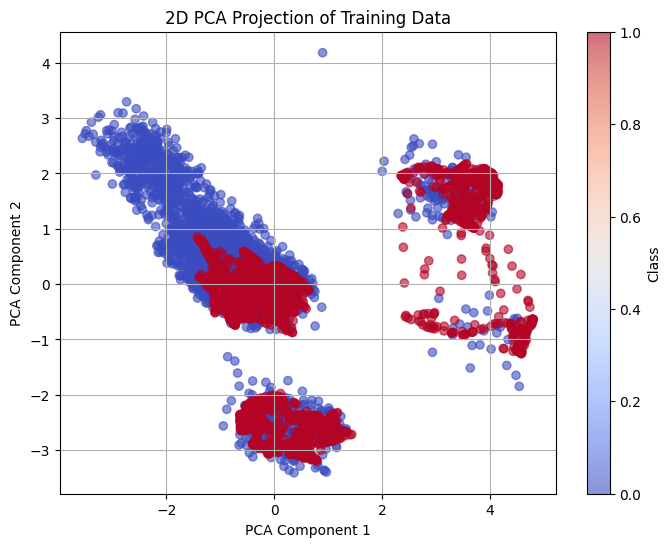

In [119]:
pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_train_scaled)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_train, cmap='coolwarm', alpha=0.6)
plt.title("2D PCA Projection of Training Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Class")
plt.grid(True)
plt.show()

In [132]:
def plot_svm_decision_boundary(X, y, kernel='linear', degree=3, C=1.0, title='SVM Decision Boundary'):
    # fitting model
    model = SVC(kernel=kernel, degree=degree, C=C)
    model.fit(X, y)

    # grid
    # step size
    h = 0.05  
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict on the grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.grid(True)
    plt.show()

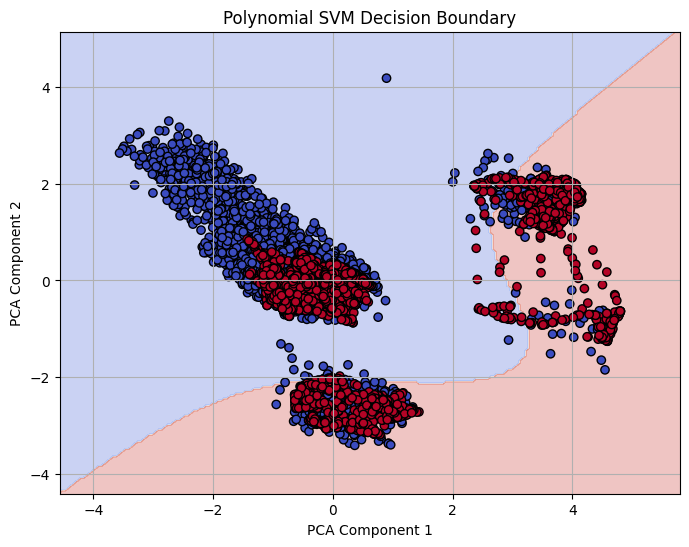

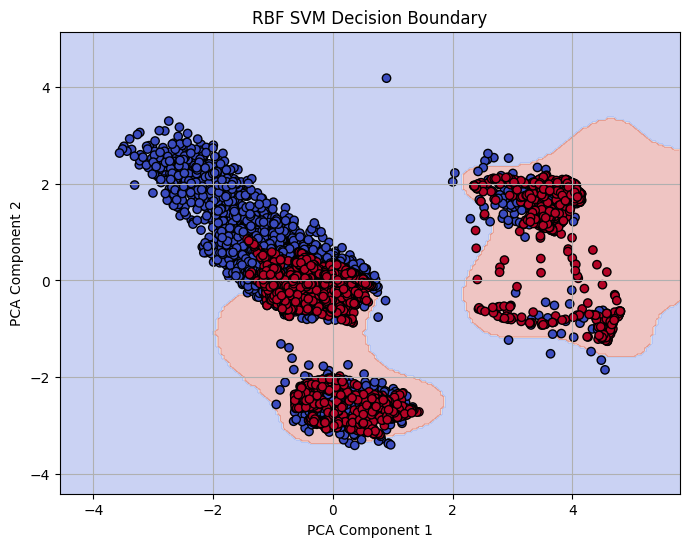

In [138]:

# Now train SVM on 2D data
plot_svm_decision_boundary(X_train_pca, y_train, kernel='poly', degree=3, title='Polynomial SVM Decision Boundary')
plot_svm_decision_boundary(X_train_pca, y_train, kernel='rbf', C=500, title='RBF SVM Decision Boundary')
#we can see thta theres more error in rbf because data is not seperated ina good way

1.  Hard SVM ->    0.7022251308900523

2.  Soft SVM ->    SVM Results:
                   Best C: 10
                   Test Accuracy: 0.7022251308900523
    
3.  RBF SVM ->  SVM Results:
                   Best C: 10
                   Best gamma: 1
                   Test Accuracy: 0.9155759162303665
    
4.  Poly SVM   ->  SVM Results:
                   Best C: 1000
                   Best degree: 4
                   Test Accuracy: 0.8756544502617801

5. Sigmoid SVM ->  SVM Results:
                   Best C: 0.1
                   Test Accuracy: 0.6714659685863874

6. RBF with (2D)PCA -> SVM Results:
                       Best C: 500
                       Best gamma: 1
                       Test Accuracy: 0.6930628272251309

7. Poly with (2D)PCA -> SVM Results:
                        Best C: 1
                        Best degree: 3
                        Test Accuracy: 0.8651832460732984

In [ ]:
#RBF without PCA performed the best concluding that the data can only be seperated in high dimensions >9D
# C used in RBF is 10 which is perfect , no overfitting or underfitting
#Limittions: very long training time, decision trees can be used instead